# Experiment No. 7

## Title
**To implement the Cohen–Sutherland Line Clipping Algorithm for clipping a line within a rectangular window**

## Objective
To clip a line segment using the Cohen–Sutherland algorithm so that only the visible portion inside a rectangular clipping window is displayed.

## Theory
The Cohen–Sutherland Line Clipping Algorithm is used in computer graphics to clip a line segment so that only the portion inside a defined rectangular window is visible.

The algorithm assigns a 4-bit region code (Outcode) to each endpoint based on its position relative to the clipping window:

- Top → 1000  
- Bottom → 0100  
- Right → 0010  
- Left → 0001  

Each point is classified as:
- Inside (0000)
- Outside (non-zero code)

### Cases:
1. **Trivial Acceptance**:  
   If both endpoints have region code 0000 → line is completely inside.

2. **Trivial Rejection**:  
   If logical AND of both region codes ≠ 0 → line is completely outside.

3. **Partial Clipping**:  
   Otherwise, the line intersects the window. Intersection points are calculated and the line is clipped accordingly.

Intersection formulas:

- For vertical boundary:
$$
x = x_{boundary}
$$
$$
y = y_1 + m(x - x_1)
$$

- For horizontal boundary:
$$
y = y_{boundary}
$$
$$
x = x_1 + \frac{(y - y_1)}{m}
$$

Where:
$$
m = \frac{y_2 - y_1}{x_2 - x_1}
$$

## Procedure
1. Define the clipping window boundaries $(x_{min}, y_{min})$ and $(x_{max}, y_{max})$.
2. Input the endpoints of the line.
3. Compute region codes for both endpoints.
4. Check for trivial acceptance or rejection.
5. If partially inside, compute intersection with clipping boundary.
6. Replace the outside point with intersection point.
7. Repeat until the line is accepted or rejected.
8. Plot the original and clipped line.

## Output
- Original line
- Clipped line inside the rectangular window
- Clipping window displayed
- Output image saved as `Exp7_Output.png`

## Result and Discussion
The Cohen–Sutherland algorithm successfully clipped the given line according to the defined window. The visible portion of the line was correctly displayed inside the clipping region. The use of region codes made the algorithm efficient in determining whether to accept, reject, or partially clip the line.

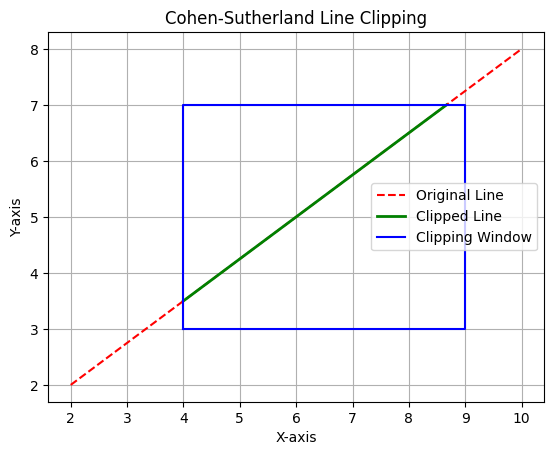

In [1]:
import matplotlib.pyplot as plt

# Define region codes
INSIDE = 0
LEFT = 1
RIGHT = 2
BOTTOM = 4
TOP = 8

def compute_code(x, y, xmin, ymin, xmax, ymax):
    code = INSIDE

    if x < xmin:
        code |= LEFT
    elif x > xmax:
        code |= RIGHT
    if y < ymin:
        code |= BOTTOM
    elif y > ymax:
        code |= TOP

    return code

def cohen_sutherland(x1, y1, x2, y2, xmin, ymin, xmax, ymax):
    code1 = compute_code(x1, y1, xmin, ymin, xmax, ymax)
    code2 = compute_code(x2, y2, xmin, ymin, xmax, ymax)

    accept = False

    while True:
        if code1 == 0 and code2 == 0:
            accept = True
            break
        elif (code1 & code2) != 0:
            break
        else:
            x = y = 0

            if code1 != 0:
                code_out = code1
            else:
                code_out = code2

            if code_out & TOP:
                x = x1 + (x2 - x1) * (ymax - y1) / (y2 - y1)
                y = ymax
            elif code_out & BOTTOM:
                x = x1 + (x2 - x1) * (ymin - y1) / (y2 - y1)
                y = ymin
            elif code_out & RIGHT:
                y = y1 + (y2 - y1) * (xmax - x1) / (x2 - x1)
                x = xmax
            elif code_out & LEFT:
                y = y1 + (y2 - y1) * (xmin - x1) / (x2 - x1)
                x = xmin

            if code_out == code1:
                x1, y1 = x, y
                code1 = compute_code(x1, y1, xmin, ymin, xmax, ymax)
            else:
                x2, y2 = x, y
                code2 = compute_code(x2, y2, xmin, ymin, xmax, ymax)

    return accept, x1, y1, x2, y2


# Example input
x1, y1 = 2, 2
x2, y2 = 10, 8

xmin, ymin = 4, 3
xmax, ymax = 9, 7

accept, cx1, cy1, cx2, cy2 = cohen_sutherland(x1, y1, x2, y2, xmin, ymin, xmax, ymax)

# Plotting
plt.plot([x1, x2], [y1, y2], 'r--', label="Original Line")

if accept:
    plt.plot([cx1, cx2], [cy1, cy2], 'g', linewidth=2, label="Clipped Line")

# Draw clipping window
plt.plot([xmin, xmax, xmax, xmin, xmin],
         [ymin, ymin, ymax, ymax, ymin], 'b', label="Clipping Window")

plt.title("Cohen-Sutherland Line Clipping")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.savefig("Exp7_Output.png")
plt.show()